### Helper Functions 

In [2]:
import os
import requests
from datetime import datetime, timedelta

def download_mcs_ddr_fullpath(start_date, end_date, output_dir):
    """
    Downloads MCS DDR files using full nested PDS path.
    Example:
        download_mcs_ddr_fullpath('2022-01-01', '2022-01-03', 'MCS_DDR')
    """

    base_volume_number = 2001
    base_date = datetime(2006, 9, 1)
    base_url_root = "https://atmos.nmsu.edu/PDS/data/"

    # Create output directory if needed
    os.makedirs(output_dir, exist_ok=True)

    # Time steps per day
    hours_list = ['00', '04', '08', '12', '16', '20']

    # Convert input dates
    start_date = datetime.fromisoformat(start_date)
    end_date = datetime.fromisoformat(end_date)

    current_date = start_date

    while current_date <= end_date:
        year_str = current_date.strftime('%Y')
        month_str = current_date.strftime('%Y%m')
        day_str = current_date.strftime('%Y%m%d')

        # Calculate months since base date
        months_since_start = (current_date.year - base_date.year) * 12 + (current_date.month - base_date.month)
        volume_number = base_volume_number + months_since_start
        volume_id = f"MROM_{volume_number:04d}"

        # Build folder URL
        folder_url = f"{base_url_root}{volume_id}/DATA/{year_str}/{month_str}/{day_str}/"

        for hour_str in hours_list:
            file_base = f"{day_str}{hour_str}_DDR"
            tab_file = f"{file_base}.TAB"
            lbl_file = f"{file_base}.LBL"

            local_tab_path = os.path.join(output_dir, tab_file)
            local_lbl_path = os.path.join(output_dir, lbl_file)

            # Skip if already downloaded
            if os.path.isfile(local_tab_path) and os.path.isfile(local_lbl_path):
                print(f"Skipping already downloaded: {tab_file}")
                continue

            try:
                print(f"Downloading: {tab_file}")

                tab_url = folder_url + tab_file
                lbl_url = folder_url + lbl_file
                print(tab_url)
                print(lbl_url)

                # Download TAB file
                tab_response = requests.get(tab_url)
                tab_response.raise_for_status()
                with open(local_tab_path, 'wb') as f:
                    f.write(tab_response.content)

                # Download LBL file
                lbl_response = requests.get(lbl_url)
                lbl_response.raise_for_status()
                with open(local_lbl_path, 'wb') as f:
                    f.write(lbl_response.content)

            except Exception as e:
                print(f"  Could not get {tab_file} ({e})")

        current_date += timedelta(days=1)

In [3]:
import re

def make_valid_name(name):
    """
    Replicates MATLAB's matlab.lang.makeValidName.
    Replaces non-alphanumeric characters with underscores.
    """
    # Remove quotes and surrounding whitespace
    name = name.replace('"', '').strip()
    # Replace non-word characters with underscores
    name = re.sub(r'\W+|^(?=\d)', '_', name)
    return name

def read_mcs_profiles(filename):
    """
    Read MCS profile .TAB file with multiple profiles.
    Returns a list of dictionaries containing metadata and vertical profile data.
    """
    try:
        with open(filename, 'r') as f:
            # Read all non-comment lines and strip whitespace
            lines = [line.strip() for line in f if line.strip() and not line.strip().startswith('#')]
    except FileNotFoundError:
        raise Exception(f"Cannot open file: {filename}")

    if len(lines) < 2:
        return []

    # Detect column headers
    meta_header = [h.strip() for h in lines[0].split(',')]
    profile_header = [h.strip() for h in lines[1].split(',')]

    def is_profile_start(l):
        # Corresponds to MATLAB: contains(l, '",') && count(l, ',') > 50
        return '",' in l and l.count(',') > 50

    profiles = []
    i = 2  # Python is 0-indexed; skip lines 0 and 1 (headers)
    
    while i < len(lines):
        line = lines[i]
        
        if is_profile_start(line):
            meta_parts = [p.strip() for p in line.split(',')]
            profile = {}

            # Assign metadata using header names
            for k in range(min(len(meta_parts), len(meta_header))):
                fieldname = make_valid_name(meta_header[k])
                val_raw = meta_parts[k].replace('"', '')
                
                # Try to convert to float, otherwise keep as string
                try:
                    profile[fieldname] = float(val_raw)
                except ValueError:
                    profile[fieldname] = val_raw

            # Prepare to collect vertical profile rows
            # We initialize lists for each profile column
            profile_table_data = {make_valid_name(h): [] for h in profile_header}
            i += 1

            # Collect vertical profile rows until the next profile starts
            while i < len(lines) and not is_profile_start(lines[i]):
                parts = [p.strip() for p in lines[i].split(',')]
                
                if len(parts) >= 3:
                    for j in range(min(len(parts), len(profile_header))):
                        colname = make_valid_name(profile_header[j])
                        try:
                            val = float(parts[j])
                        except ValueError:
                            val = float('nan')
                        profile_table_data[colname].append(val)
                i += 1
            
            # Merge the profile table data into the main profile dictionary
            profile.update(profile_table_data)
            profiles.append(profile)
        else:
            i += 1

    return profiles

### Process Single MCS Record 

In [16]:
# Store date ranges in a list of tuples (start, end)
timeStart = '2015-06-01'
timeEnd = '2015-06-01'

data_dir = 'MCS_DDR'

# Loop through each range
print("Downloading data")
download_mcs_ddr_fullpath(timeStart, timeEnd, data_dir)

Skipping already downloaded: 2015060100_DDR.TAB
Skipping already downloaded: 2015060104_DDR.TAB
Skipping already downloaded: 2015060108_DDR.TAB
Skipping already downloaded: 2015060112_DDR.TAB
Skipping already downloaded: 2015060116_DDR.TAB
Skipping already downloaded: 2015060120_DDR.TAB


In [17]:
import pandas as pd
import numpy as np

# Parameters
hours = np.arange(0, 21, 4) 
lat_min, lat_max = -90, 90
lon_min1, lon_max1 = 0, 180
lon_min2, lon_max2 = -180, -1

alt_max = 20

# %% Date range
t0 = pd.to_datetime(timeStart)
t1 = pd.to_datetime(timeEnd)

# Generate a range of dates (inclusive of start and end)
dates = pd.date_range(start=t0, end=t1)
n_days = len(dates)

# Preallocate list: one dictionary (struct) per day
all_data = [None] * n_days

In [20]:
import os
import numpy as np
import scipy.io as sio
from datetime import datetime

print("Starting processing loop...")

for i, day in enumerate(dates):
    # Format date as yyyymmdd (e.g., 20240301)
    yyyymmdd = day.strftime('%Y%m%d')
    
    fname = f"{yyyymmdd}_MCS.mat"
    local_mat_path = os.path.join(data_dir, fname)

    if os.path.exists(local_mat_path):
        # -------- use cached .mat --------
        s = sio.loadmat(local_mat_path)
        print(f"Loaded cached {local_mat_path}")
        
        # Store for this day in the list
        all_data[i] = {
            'date': day,
            'lon_all': s['lon_all'],
            'lat_all': s['lat_all'],
            'alt_all': s['alt_all'],
            'dust_all': s['dust_all'],
            'press_all': s['press_all'],
            'temp_all': s['temp_all'],
            'H2Oice_all': s['H2Oice_all']
        }
        print("Used cached .mat file")

    else:
        # Init containers for THIS day (using lists for efficient appending)
        lon_day, lat_day, alt_day = [], [], []
        dust_day, press_day, temp_day, h2o_day = [], [], [], []

        for h in hours:
            filename = f"{yyyymmdd}{h:02d}_DDR.TAB"
            filepath = os.path.join(data_dir, filename)

            if not os.path.exists(filepath):
                print(f"Missing file: {filepath}")
                continue

            try:
                # Assuming you have a python version of read_mcs_profiles
                profiles = read_mcs_profiles(filepath)
            except Exception as e:
                print(f"Error reading file {filepath}: {e}")
                continue

            # Select profiles by lat/lon
            for p in profiles:
                latp = p.get('Profile_lat')
                lonp = p.get('Profile_lon')

                if np.isnan(latp) or np.isnan(lonp):
                    continue

                in_lon_range = (lon_min1 <= lonp <= lon_max1) or \
                               (lon_min2 <= lonp <= lon_max2)

                if lat_min <= latp <= lat_max and in_lon_range:
                    try:
                        # Extract data (assuming these are numpy arrays inside the profile dict)
                        alt = np.array(p['Alt'])
                        dust = np.array(p['Dust'])
                        h2o = np.array(p['H2Oice'])
                        pres = np.array(p['Pres'])
                        tmp = np.array(p['T'])
                        lat = np.array(p['Lat'])
                        lon = np.array(p['Lon'])

                        # Logical indexing (validity mask)
                        valid = (alt >= 0) & (alt <= alt_max) & \
                                (dust > -9000) & (lat > -9000) & \
                                (lon > -9000) & (h2o > -9000)

                        if not np.any(valid):
                            continue

                        # Filter arrays
                        alt, dust, pres = alt[valid], dust[valid], pres[valid]
                        tmp, lat, lon = tmp[valid], lat[valid], lon[valid]
                        
                        # Water ice specific filter
                        validH2O = h2o[valid] # Simplified based on your MATLAB logic
                        
                        # Wrap longitudes to 0–360
                        lon[lon < 0] += 360

                        # Append to day lists
                        lon_day.extend(lon)
                        lat_day.extend(lat)
                        alt_day.extend(alt)
                        dust_day.extend(dust)
                        press_day.extend(pres)
                        temp_day.extend(tmp)
                        h2o_day.extend(validH2O)

                    except KeyError:
                        continue

        # Convert day lists to numpy arrays for storage
        all_data[i] = {
            'date': day,
            'lon_all': np.array(lon_day),
            'lat_all': np.array(lat_day),
            'alt_all': np.array(alt_day),
            'dust_all': np.array(dust_day),
            'press_all': np.array(press_day),
            'temp_all': np.array(temp_day),
            'H2Oice_all': np.array(h2o_day)
        }
        
        # Save this day to its own MAT file (keeps it compatible with MATLAB)
        mdict = {k: v for k, v in all_data[i].items() if k != 'date'}
        sio.savemat(local_mat_path, mdict)
        print(f"Finished {yyyymmdd} (stored in all_data[{i}])")

print("Done.")


Starting processing loop...
Finished 20150601 (stored in all_data[0])
Done.


In [21]:
import numpy as np

n_days = len(all_data)

# Interpolation Grid (common for all days)
min_alt    = 4
max_alt    = 20
alt_points = 10
g_points   = 200

# Longitude wrapping (modulus)
lon_min2_wrapped = lon_min2 % 360
lon_max2_wrapped = lon_max2 % 360

# Linear spacing for grids
lon_grid = np.linspace(min(lon_min1, lon_min2_wrapped), max(lon_max1, lon_max2_wrapped), g_points)
lat_grid = np.linspace(-90, 90, g_points)
alt_grid = np.linspace(min_alt, max_alt, alt_points)

# Meshgrid generation
# indexing='xy' in NumPy matches MATLAB's meshgrid behavior for 3D (X, Y, Z)
lon_mesh, lat_mesh, alt_mesh = np.meshgrid(lon_grid, lat_grid, alt_grid, indexing='xy')

n_lat = len(lat_grid)

# Storage for daily zonal-mean tau and waterIce
# np.full creates an array of a specific shape filled with a value (NaN here)
zonal_tau = np.full((n_lat, n_days), np.nan)
zonal_water_ice = np.full((n_lat, n_days), np.nan)

# Constants
water_s_new = 0
tau_new = 0

/var/tmp/pbs.2985508.pbs-7/ipykernel_344956/3049054242.py:73: RuntimeWarning: Mean of empty slice
  temp_column   = np.nanmean(temp_interp, axis=2)
/var/tmp/pbs.2985508.pbs-7/ipykernel_344956/3049054242.py:75: RuntimeWarning: Mean of empty slice
  tempress_column = np.nanmean(tempress_interp, axis=2)


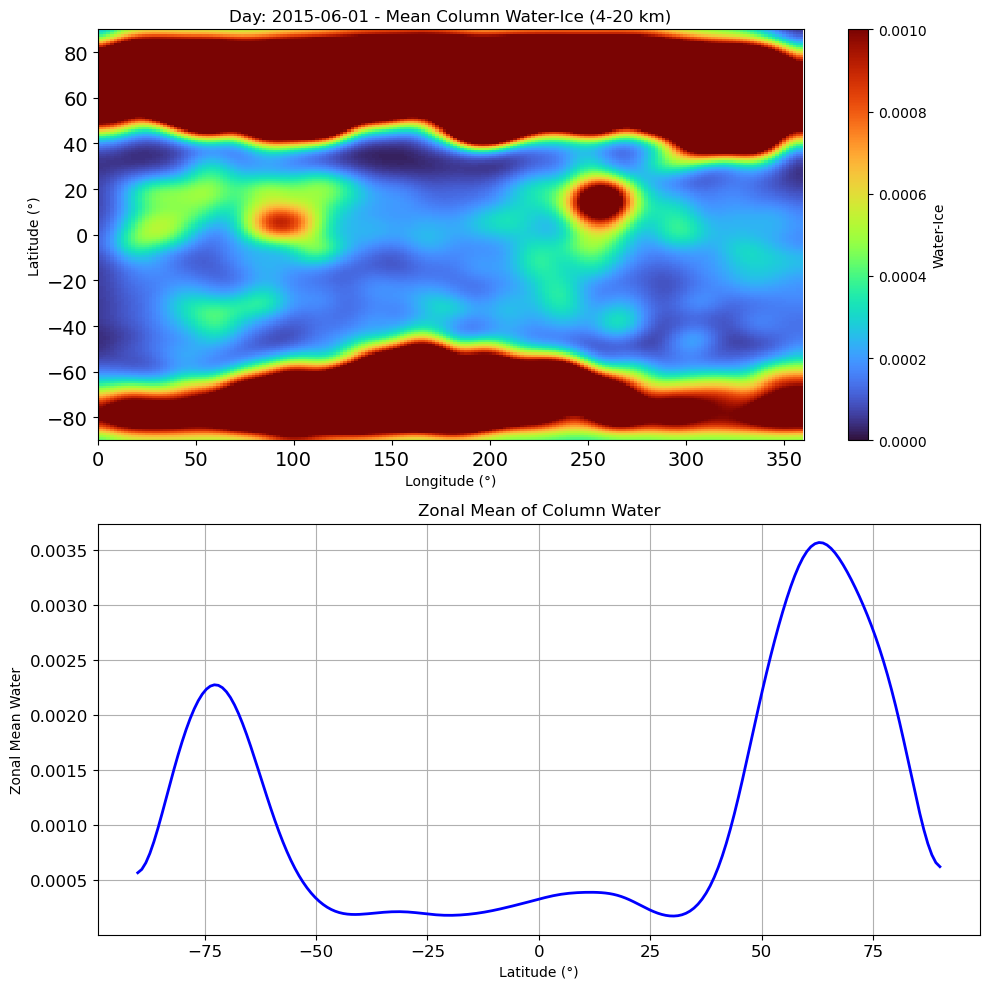

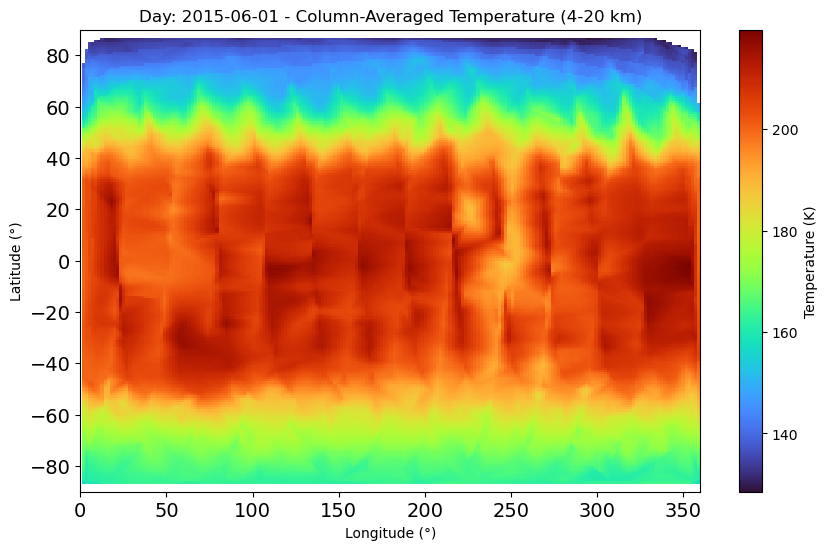

/var/tmp/pbs.2985508.pbs-7/ipykernel_344956/3049054242.py:154: RuntimeWarning: Mean of empty slice
  zonal_tau[:, i] = np.nanmean(tau, axis=1)


In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

# Loop over days
for i, d in enumerate(all_data):
    # MATLAB 1-based index for printing
    day_idx = i + 1 
    
    if not d or 'lon_all' not in d or len(d['lon_all']) == 0:
        print(f"No data for day index {day_idx}")
        continue

    # Extract arrays from dictionary
    lon_all    = np.array(d['lon_all'])
    lat_all    = np.array(d['lat_all'])
    alt_all    = np.array(d['alt_all'])
    dust_all   = np.array(d['dust_all'])
    press_all  = np.array(d['press_all'])
    temp_all   = np.array(d['temp_all'])
    h2o_ice_all = np.array(d.get('H2Oice_all', [])) # Use .get for safety

    # Basic validity mask
    # We use parentheses because bitwise '&' has high precedence in Python
    valid = (alt_all >= min_alt) & (alt_all <= max_alt) & \
            (dust_all > -9000) & (press_all > -9000) & (temp_all > -9000) & \
            (~np.isnan(lon_all)) & (~np.isnan(lat_all)) & (~np.isnan(alt_all)) & \
            (~np.isnan(dust_all)) & (~np.isnan(press_all)) & (~np.isnan(temp_all))

    if not np.any(valid):
        print(f"No valid points for day index {day_idx}")
        continue

    # Derived field (assuming press_all() was intended as a copy or slice)
    press_temp = press_all.copy()

    # For water, require its own validity
    valid_water = valid & (h2o_ice_all > -9000) & (~np.isnan(h2o_ice_all))

    # Prepare coordinate points for SciPy (N x 3 array)
    points = np.column_stack((lon_all[valid], lat_all[valid], alt_all[valid]))
    
    # Query points from our meshgrid (defined in the previous step)
    # We pass these as a tuple of arrays
    query_points = (lon_mesh, lat_mesh, alt_mesh)

    # Evaluate on grid using linear interpolation
    # fill_value=np.nan matches MATLAB's 'none' extrapolation behavior
    dust_interp = griddata(points, dust_all[valid], query_points, method='linear', fill_value=np.nan)
    press_interp = griddata(points, press_all[valid], query_points, method='linear', fill_value=np.nan)
    temp_interp = griddata(points, temp_all[valid], query_points, method='linear', fill_value=np.nan)
    tempress_interp = griddata(points, press_temp[valid], query_points, method='linear', fill_value=np.nan)

    # Handle Water interpolation
    if np.any(valid_water):
        water_points = np.column_stack((lon_all[valid_water], lat_all[valid_water], alt_all[valid_water]))
        water_interp = griddata(water_points, h2o_ice_all[valid_water], query_points, method='linear', fill_value=np.nan)
    else:
        water_interp = np.zeros(lon_mesh.shape)  # Or np.full(lon_mesh.shape, np.nan)

    # --- 1. Clean NaNs for integrations ---
    # We use np.isnan() for boolean indexing
    dust_interp[np.isnan(dust_interp)] = 0
    press_interp[np.isnan(press_interp)] = 0
    # temp_interp and tempress_interp stay as NaN where missing (standard behavior)
    water_interp[np.isnan(water_interp)] = 0
    
    # --- 2. Vertical integration / averaging ---
    # axis=2 in Python corresponds to the 3rd dimension in MATLAB
    dust_column   = np.nanmean(dust_interp, axis=2)
    water_column  = np.nanmean(water_interp, axis=2)
    temp_column   = np.nanmean(temp_interp, axis=2)
    press_column  = np.nanmean(press_interp, axis=2)
    tempress_column = np.nanmean(tempress_interp, axis=2)
    
    # --- 3. Tau proxy ---
    tau = dust_column / tempress_column
    # Replace infinities (from division by zero) with NaN
    tau[~np.isfinite(tau)] = np.nan
    
    # --- 4. Smooth fields ---
    # scipy's gaussian_filter needs sigma. 
    # We fill NaNs with 0 before filtering to prevent NaN propagation
    tau_smoothed    = gaussian_filter(np.nan_to_num(tau), sigma=5)
    temp_s          = gaussian_filter(np.nan_to_num(temp_column), sigma=5)
    water_s         = gaussian_filter(np.nan_to_num(water_column), sigma=5)
    press_s         = gaussian_filter(np.nan_to_num(press_column), sigma=5)
    
    # Accumulate totals
    water_s_new += water_s
    tau_new += tau_smoothed
    
    # --- 5. Plotting ---
    # Assuming 'dates' is a list of datetime objects
    day_str = dates[i].strftime('%Y-%m-%d')
    
    plt.figure(238, figsize=(10, 10))
    plt.clf()
    
    # Subplot 1: Map
    plt.subplot(2, 1, 1)
    # pcolormesh is the standard 2D equivalent of surf + view(2)
    mesh = plt.pcolormesh(lon_grid, lat_grid, water_s, shading='auto', cmap='turbo')
    plt.colorbar(mesh, label='Water-Ice')
    plt.clim(0, 0.001)  # Replaces caxis
    
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    plt.title(f'Day: {day_str} - Mean Column Water-Ice ({min_alt}-{max_alt} km)')
    plt.ylim(-90, 90)
    plt.xlim(0, 360)
    plt.tick_params(labelsize=14)
    
    # Subplot 2: Zonal Mean
    plt.subplot(2, 1, 2)
    zonal_mean_water = np.nanmean(water_s, axis=1) # axis 1 is Lon in a (Lat, Lon) array
    plt.plot(lat_grid, zonal_mean_water, 'b-', linewidth=2)
    
    plt.xlabel('Latitude (°)')
    plt.ylabel('Zonal Mean Water')
    plt.title('Zonal Mean of Column Water')
    plt.grid(True)
    plt.tick_params(labelsize=12)
    
    plt.tight_layout()
    plt.show()

    # --- Figure 2: Temperature (or Tau) map ---
    plt.figure(239, figsize=(10, 6))
    plt.clf()
    
    # Using pcolormesh for the 2D surface plot
    # Note: if tau is [Lat x Lon], lon_grid and lat_grid should match the dimensions
    mesh2 = plt.pcolormesh(lon_grid, lat_grid, temp_column, shading='auto', cmap='turbo')
    
    plt.xlabel('Longitude (°)')
    plt.ylabel('Latitude (°)')
    # plt.zlabel doesn't exist in 2D plots; usually handled by colorbar label
    plt.title(f'Day: {day_str} - Column-Averaged Temperature ({min_alt}-{max_alt} km)')
    
    cb = plt.colorbar(mesh2)
    cb.set_label('Temperature (K)') # Or 'Tau' based on your preference
    
    plt.tick_params(labelsize=14)
    plt.ylim(-90, 90)
    plt.xlim(0, 360)
    
    plt.show()
    
    # --- Store zonal-mean for lat-day arrays ---
    # In MATLAB: zonal_tau(:, i) = nanmean(tau, 2)
    # axis=1 in Python performs the average across the columns (Longitude)
    zonal_tau[:, i] = np.nanmean(tau, axis=1)
    zonal_water_ice[:, i] = np.nanmean(water_s, axis=1)

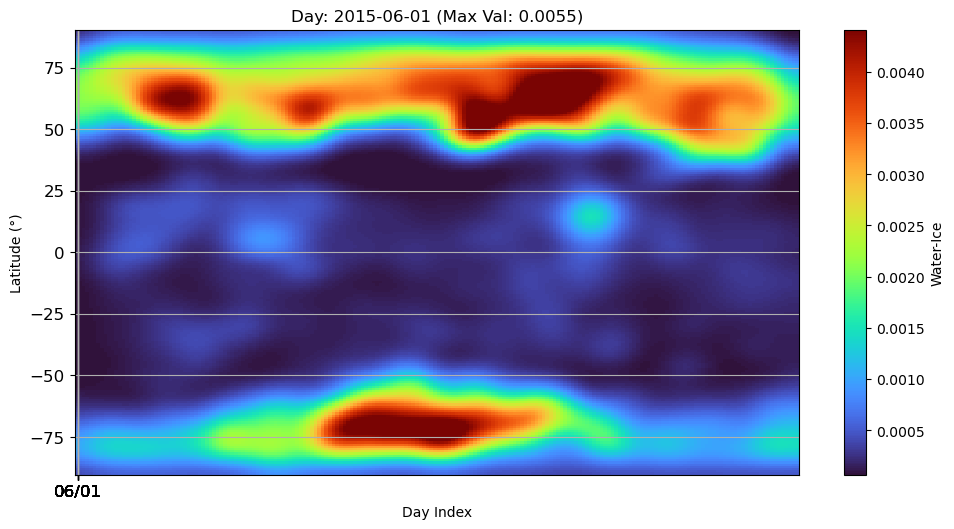

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter

# --- 1. Normalization (Per-Column/Per-Day) ---
def normalize_range(data):
    # Calculate min and max for each column (axis=0)
    col_min = np.nanmin(data, axis=0)
    col_max = np.nanmax(data, axis=0)
    # Avoid division by zero if a column is all the same value
    denom = col_max - col_min
    denom[denom == 0] = 1
    return (data - col_min) / denom

zonal_tau_norm = normalize_range(zonal_tau)
zonal_water_ice_norm = normalize_range(zonal_water_ice)

# --- 2. Create Meshgrid for Plotting ---
# days: 1 to n_days
day_indices = np.arange(1, n_days + 1)
# indexing='xy' matches MATLAB's meshgrid behavior
day_mesh, lat_mesh_2d = np.meshgrid(day_indices, lat_grid, indexing='xy')

# --- 3. Gaussian Filtering ---
# Replaces imgaussfilt. Fill NaNs with 0 to prevent edge bleeding.
zonal_tau_interp = gaussian_filter(np.nan_to_num(zonal_tau_norm), sigma=5)
zonal_water_ice_interp = gaussian_filter(np.nan_to_num(zonal_water_ice_norm), sigma=5)

# --- 4. Plotting ---
plt.figure(2352181, figsize=(10, 10))
plt.clf()

# Subplot 1: Hovmöller Plot (Lat vs Day)
plt.subplot(2, 1, 1)

plt.xlabel('Day Index')
plt.ylabel('Latitude (°)')

# Custom X-Ticks for dates
# Select roughly 10 evenly spaced indices
tick_indices = np.linspace(0, n_days - 1, 10, dtype=int)
# Get the day numbers (1-indexed) for those indices
xticks = day_indices[tick_indices]
# Format the dates for those indices
xtick_labels = [dates[idx].strftime('%m/%d') for idx in tick_indices]

plt.xticks(xticks, xtick_labels)
plt.tick_params(labelsize=14)

# Subplot 2: Latitude Profile (Mean over all days)
plt.subplot(2, 1, 1)
# 1. Use 'nearest' or 'linear' without zeroing out NaNs first to see the 'real' data shape
# 2. Use a robust color limit
v_min = np.nanpercentile(water_s, 2)  # 2nd percentile
v_max = np.nanpercentile(water_s, 98) # 98th percentile

mesh = plt.pcolormesh(lon_grid, lat_grid, water_s, 
                      shading='auto', 
                      cmap='turbo',
                      vmin=v_min, 
                      vmax=v_max)

plt.colorbar(mesh, label='Water-Ice')
plt.title(f"Day: {day_str} (Max Val: {np.nanmax(water_s):.4f})")

plt.grid(True)
plt.tick_params(labelsize=12)
plt.tight_layout()
plt.show()

### Convert tar.gz Archive To CSV

In [1]:
import tarfile
import csv
import re

ARCHIVE = "possible_detection_F.tar.gz"
OUTPUT_FILE =  "possible_detection_F.csv"

# Regex to capture date, lat range, lon range
pattern = re.compile(
    r'_(\d{4}-\d{2}-\d{2})_(-?\d+)to(-?\d+)_(-?\d+)to(-?\d+)\.tif$'
)

def extract_to_csv(tar_gz_path, output_csv):
    with tarfile.open(tar_gz_path, "r|gz") as tar, open(output_csv, "w", newline="") as f:
        writer = csv.writer(f)
        
        # header
        writer.writerow(["filename", "date", "lat_min", "lat_max", "lon_min", "lon_max"])
        
        for member in tar:
            name = member.name
            
            match = pattern.search(name)
            if match:
                date, lat_min, lat_max, lon_min, lon_max = match.groups()
                
                writer.writerow([
                    name,
                    date,
                    int(lat_min),
                    int(lat_max),
                    int(lon_min),
                    int(lon_max)
                ])

# Example usage
extract_to_csv(ARCHIVE, OUTPUT_FILE)

ReadError: unexpected end of data

### Get MCS Metrics From CSV (Improved)
- Restrict altitude to 8km to 2km
- Calculate global average of band 5deg above and 5deg below dust storm
- Add solar longitude

In [4]:
import math
from datetime import datetime

def earth_date_to_mars_ls(date_str):
    """
    Converts an Earth date (dd/mm/yyyy) to Mars Solar Longitude (Ls).
    Assumes the time is 00:00:00 UTC on the given date.
    """
    # 1. Parse the date string
    dt = datetime.strptime(date_str, "%Y-%m-%d")
    
    # 2. Calculate Julian Date (JD)
    # Python's toordinal() returns days since Jan 1, 1 AD.
    # Adding 1721424.5 converts it to standard Julian Date at 00:00 UTC.
    jd = dt.toordinal() + 1721424.5
    
    # 3. Calculate days since J2000 epoch (Jan 1, 2000 12:00 UTC)
    delta_t = jd - 2451545.0
    
    # 4. Calculate Mars Mean Anomaly (M) in degrees
    m_deg = (19.3870 + 0.52402075 * delta_t) % 360.0
    m_rad = math.radians(m_deg)
    
    # 5. Calculate Equation of Center (alpha) in degrees
    # This polynomial expansion corrects for Mars' elliptical orbit
    alpha = (
        (10.691 + 3.0e-7 * delta_t) * math.sin(m_rad) +
        0.623 * math.sin(2 * m_rad) +
        0.050 * math.sin(3 * m_rad) +
        0.005 * math.sin(4 * m_rad) +
        0.0005 * math.sin(5 * m_rad)
    )
    
    # 6. Calculate Solar Longitude (Ls)
    # 250.992 degrees is the Ls of Mars' perihelion
    ls = (m_deg + alpha + 250.992) % 360.0
    
    return ls

In [5]:
import pandas as pd
import numpy as np

import scipy.io as sio
from scipy.interpolate import griddata
from scipy.ndimage import gaussian_filter

data_dir = "MCS_DDR"

ARCHIVE = "possible_detection_F.tar.gz"
OUTPUT_FILE =  "possible_detection_F.csv"
OUTPUT_FILE_WITH_MCS = "possible_detection_F_MCS.csv"

df = pd.read_csv(OUTPUT_FILE)

for index, row in df.iterrows():
    
    date = row['date']
    
    download_mcs_ddr_fullpath(date, date, data_dir)

    # Parameters
    hours = np.arange(0, 21, 4) 
    lat_min, lat_max = -90, 90
    lon_min1, lon_max1 = 0, 180
    lon_min2, lon_max2 = -180, -1
    alt_max = 20

    # Initialise datetime struct
    t0 = pd.to_datetime(date)
    dates = [t0]          
    n_days = 1
    all_data = None

    # Create .mat file for particular date
    yyyymmdd = date.replace("-", "")
    fname = f"{yyyymmdd}_MCS.mat"
    local_mat_path = os.path.join(data_dir, fname)

    if os.path.exists(local_mat_path):
        s = sio.loadmat(local_mat_path)
        print(f"Loaded cached {local_mat_path}")
        
        # Store for this day in the list
        all_data = {
            'date': date,
            'lon_all': s['lon_all'],
            'lat_all': s['lat_all'],
            'alt_all': s['alt_all'],
            'dust_all': s['dust_all'],
            'press_all': s['press_all'],
            'temp_all': s['temp_all'],
            'H2Oice_all': s['H2Oice_all']
        }

    else:
        # Init containers for THIS day (using lists for efficient appending)
        lon_day, lat_day, alt_day = [], [], []
        dust_day, press_day, temp_day, h2o_day = [], [], [], []

        for h in hours:
            filename = f"{yyyymmdd}{h:02d}_DDR.TAB"
            filepath = os.path.join(data_dir, filename)

            if not os.path.exists(filepath):
                print(f"Missing file: {filepath}")
                continue

            try:
                # Assuming you have a python version of read_mcs_profiles
                profiles = read_mcs_profiles(filepath)
            except Exception as e:
                print(f"Error reading file {filepath}: {e}")
                continue

            # Select profiles by lat/lon
            for p in profiles:
                latp = p.get('Profile_lat')
                lonp = p.get('Profile_lon')

                if np.isnan(latp) or np.isnan(lonp):
                    continue

                in_lon_range = (lon_min1 <= lonp <= lon_max1) or (lon_min2 <= lonp <= lon_max2)

                if lat_min <= latp <= lat_max and in_lon_range:
                    try:
                        alt = np.array(p['Alt'])
                        dust = np.array(p['Dust'])
                        h2o = np.array(p['H2Oice'])
                        pres = np.array(p['Pres'])
                        tmp = np.array(p['T'])
                        lat = np.array(p['Lat'])
                        lon = np.array(p['Lon'])

                        # Logical indexing (validity mask)
                        valid = (alt >= 0) & (alt <= alt_max) & \
                                (dust > -9000) & (lat > -9000) & \
                                (lon > -9000) & (h2o > -9000)

                        if not np.any(valid):
                            continue

                        # Filter arrays
                        alt, dust, pres = alt[valid], dust[valid], pres[valid]
                        tmp, lat, lon = tmp[valid], lat[valid], lon[valid]
                        
                        # Water ice specific filter
                        validH2O = h2o[valid] # Simplified based on your MATLAB logic
                        
                        # Wrap longitudes to 0–360
                        lon[lon < 0] += 360

                        # Append to day lists
                        lon_day.extend(lon)
                        lat_day.extend(lat)
                        alt_day.extend(alt)
                        dust_day.extend(dust)
                        press_day.extend(pres)
                        temp_day.extend(tmp)
                        h2o_day.extend(validH2O)

                    except KeyError:
                        continue

        # Convert day lists to numpy arrays for storage
        all_data = {
            'date': date,
            'lon_all': np.array(lon_day),
            'lat_all': np.array(lat_day),
            'alt_all': np.array(alt_day),
            'dust_all': np.array(dust_day),
            'press_all': np.array(press_day),
            'temp_all': np.array(temp_day),
            'H2Oice_all': np.array(h2o_day)
        }

        # Save this day to its own MAT file (keeps it compatible with MATLAB)
        mdict = {k: v for k, v in all_data.items() if k != 'date'}
        sio.savemat(local_mat_path, mdict)
        print(f"Finished {yyyymmdd}")

    print("Starting processing of .mat file")
    
    # Interpolation Grid (common for all days)
    min_alt    = 8
    max_alt    = 20
    alt_points = 10
    g_points   = 200
    
    # Longitude wrapping (modulus)
    lon_min2_wrapped = lon_min2 % 360
    lon_max2_wrapped = lon_max2 % 360
    
    # Linear spacing for grids
    lon_grid = np.linspace(min(lon_min1, lon_min2_wrapped), max(lon_max1, lon_max2_wrapped), g_points)
    lat_grid = np.linspace(-90, 90, g_points)
    alt_grid = np.linspace(min_alt, max_alt, alt_points)
    
    # Meshgrid generation
    # indexing='xy' in NumPy matches MATLAB's meshgrid behavior for 3D (X, Y, Z)
    lon_mesh, lat_mesh, alt_mesh = np.meshgrid(lon_grid, lat_grid, alt_grid, indexing='xy')
    
    n_lat = len(lat_grid)
    
    # Storage for daily zonal-mean tau and waterIce
    # np.full creates an array of a specific shape filled with a value (NaN here)
    zonal_tau = np.full((n_lat, n_days), np.nan)
    zonal_water_ice = np.full((n_lat, n_days), np.nan)
    
    # Constants
    water_s_new = 0
    tau_new = 0
    water_s = 0
    tau = 0

    d = all_data

    if not d or 'lon_all' not in d or len(d['lon_all']) == 0:
        print("No data available")
    else:
        # Extract arrays
        lon_all     = np.array(d['lon_all']) 
        lat_all     = np.array(d['lat_all'])
        alt_all     = np.array(d['alt_all'])
        dust_all    = np.array(d['dust_all'])
        press_all   = np.array(d['press_all'])
        temp_all    = np.array(d['temp_all'])
        h2o_ice_all = np.array(d.get('H2Oice_all', []))
    
        # Valid mask
        valid = (
            (alt_all >= min_alt) & (alt_all <= max_alt) &
            (dust_all > -9000) & (press_all > -9000) & (temp_all > -9000) &
            (~np.isnan(lon_all)) & (~np.isnan(lat_all)) & (~np.isnan(alt_all)) &
            (~np.isnan(dust_all)) & (~np.isnan(press_all)) & (~np.isnan(temp_all))
        )
    
        if not np.any(valid):
            print("No valid points")
        else:
            press_temp = press_all.copy()
            valid_water = valid & (h2o_ice_all > -9000) & (~np.isnan(h2o_ice_all))
    
            # Interpolation setup
            points = np.column_stack((lon_all[valid], lat_all[valid], alt_all[valid]))
            query_points = (lon_mesh, lat_mesh, alt_mesh)
    
            dust_interp = griddata(points, dust_all[valid], query_points, method='linear', fill_value=np.nan)
            temp_interp = griddata(points, temp_all[valid], query_points, method='linear', fill_value=np.nan)
            tempress_interp = griddata(points, press_temp[valid], query_points, method='linear', fill_value=np.nan)
    
            if np.any(valid_water):
                water_points = np.column_stack((lon_all[valid_water], lat_all[valid_water], alt_all[valid_water]))
                water_interp = griddata(water_points, h2o_ice_all[valid_water], query_points, method='linear', fill_value=np.nan)
            else:
                water_interp = np.zeros(lon_mesh.shape)
    
            # Clean NaNs
            dust_interp[np.isnan(dust_interp)] = 0
            water_interp[np.isnan(water_interp)] = 0
    
            # Vertical stats
            dust_column    = np.nanmean(dust_interp, axis=2)
            water_column   = np.nanmean(water_interp, axis=2)
            temp_column    = np.nanmean(temp_interp, axis=2)
            tempress_column = np.nanmean(tempress_interp, axis=2)
    
            # Tau
            tau = dust_column / tempress_column
            tau[~np.isfinite(tau)] = np.nan
    
            # Smooth
            tau_smoothed = gaussian_filter(np.nan_to_num(tau), sigma=5)
            temp_s       = gaussian_filter(np.nan_to_num(temp_column), sigma=5)
            water_s      = gaussian_filter(np.nan_to_num(water_column), sigma=5)
    
            # Accumulate
            water_s_new += water_s
            tau_new += tau_smoothed

            # --- MODIFIED SECTION ---
            
            # Extract 2D grids for masking
            lat_2d = lat_mesh[:, :, 0]
            lon_2d = lon_mesh[:, :, 0]

            # 1. Mask for 5 latitudes above AND below the bounding box (across all longitudes)
            surround_mask = (
                ((lat_2d > row['lat_max']) & (lat_2d <= row['lat_max'] + 5)) |
                ((lat_2d >= row['lat_min'] - 5) & (lat_2d < row['lat_min']))
            )

            '''
            # Compute global mask
            box_center_lat = (row['lat_min'] + row['lat_max']) / 2
            
            if box_center_lat >= 0:
                # Northern Hemisphere
                surround_mask = lat_2d >= 0
            else:
                # Southern Hemisphere
                surround_mask = lat_2d < 0
            '''
            
            # Calculate means for this surrounding latitudinal band
            surround_water_mean = np.nanmean(water_s[surround_mask])
            surround_temp_mean  = np.nanmean(temp_s[surround_mask])

            # 2. Mask for the actual dust storm bounding box
            storm_mask = (
                (lat_2d >= row['lat_min']) & (lat_2d <= row['lat_max']) &
                (lon_2d >= row['lon_min']) & (lon_2d <= row['lon_max'])
            )
            
            water_mask_values = water_s[storm_mask]
            dust_storm_water_mean = np.nanmean(water_mask_values)
            
            temp_mask_values = temp_s[storm_mask]
            dust_storm_temp_mean = np.nanmean(temp_mask_values)

            # Build row
            out_row = pd.DataFrame([{
                "date": date,
                "solar_longitude": earth_date_to_mars_ls(date),
                "lat_min": row['lat_min'],
                "lat_max": row['lat_max'],
                "lon_min": row['lon_min'],
                "lon_max": row['lon_max'],
                "hemisphere_water_mean": surround_water_mean,
                "hemisphere_temp_mean": surround_temp_mean,
                "storm_water_mean": dust_storm_water_mean,
                "storm_temp_mean": dust_storm_temp_mean
            }])

            out_row.to_csv(OUTPUT_FILE_WITH_MCS, mode="a", header=False, index=False)

Finished 20160210
Starting processing of .mat file


### Plot Storm Water Content and Temp vs Avg Water Content and Temp

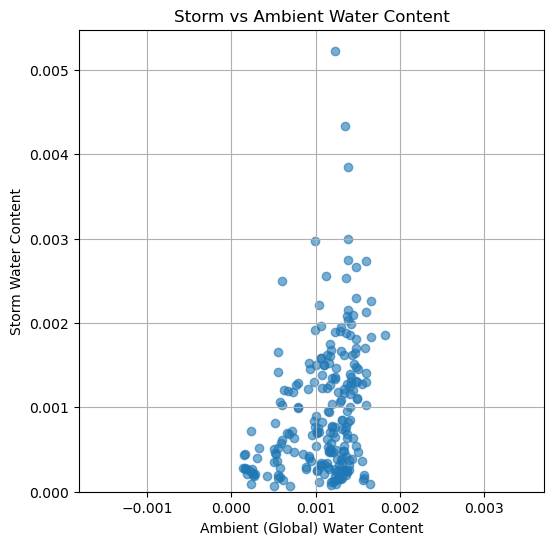

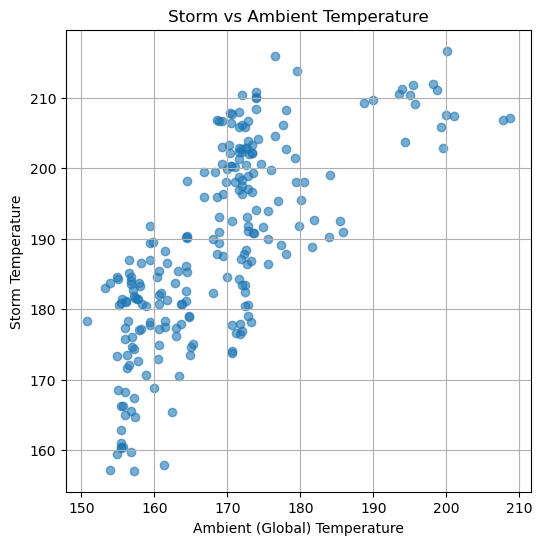

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df_j = pd.read_csv("possible_detection_J_MCS.csv")
df_f = pd.read_csv("possible_detection_F_MCS.csv")
df = pd.concat([df_j, df_f])

# ---- Scatter: Water Content ----
plt.figure(figsize=(6, 6))
plt.scatter(df["global_water_mean"], df["storm_water_mean"], alpha=0.6)
plt.title(f"Storm vs Ambient Water Content")
plt.xlabel("Ambient (Global) Water Content")
plt.ylabel("Storm Water Content")
plt.grid(True)
plt.axis('equal')
plt.xlim(left=0)
plt.ylim(bottom=0)
plt.show()

# ---- Scatter: Temperature ----
plt.figure(figsize=(6, 6))
plt.scatter(df["global_temp_mean"], df["storm_temp_mean"], alpha=0.6)
plt.title(f"Storm vs Ambient Temperature")
plt.xlabel("Ambient (Global) Temperature")
plt.ylabel("Storm Temperature")
plt.grid(True)
plt.show()

### Plot Storm Water/Temp vs Ambient wrt Season

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("possible_detection_J_MCS.csv")

df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")
df["L_s"] = df["Date"].apply(earth_date_to_mars_ls)

# ---- Scatter: Water Content ----
plt.figure(figsize=(6, 6))
sc1 = plt.scatter(df["global_water_mean"], df["storm_water_mean"], c=df["L_s"], cmap="viridis", alpha=0.5)
plt.title("Storm vs Ambient Water Content")
plt.xlabel("Global Water Content")
plt.ylabel("Storm Water Content")
plt.grid(True)
plt.axis('auto')
plt.xlim(left=0, right=0.0015)
plt.ylim(bottom=0)
cbar1 = plt.colorbar(sc1)
cbar1.set_label("Solar Longitude")
plt.show()

# ---- Scatter: Temperature ----
plt.figure(figsize=(6, 6))
sc2 = plt.scatter(df["global_temp_mean"], df["storm_temp_mean"], c=df["L_s"], cmap="viridis", alpha=0.5)
plt.title("Storm vs Ambient Temperature")
plt.xlabel("Global Temperature")
plt.ylabel("Storm Temperature")
plt.grid(True)
plt.axis('auto')
plt.xlim(left=0)
plt.ylim(bottom=0)
cbar2 = plt.colorbar(sc2)
cbar2.set_label("Solar Longitude")
plt.show()

/var/tmp/pbs.2862796.pbs-7/ipykernel_4043689/2314660405.py:7: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df["Date"] = pd.to_datetime(df["Date"]).dt.strftime("%Y-%m-%d")


NameError: name 'earth_date_to_mars_ls' is not defined

### Plot Storm Water/Temp vs Ambient wrt Latitude

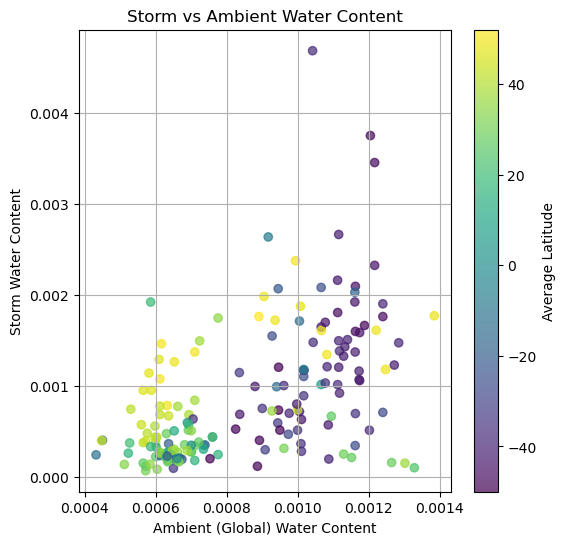

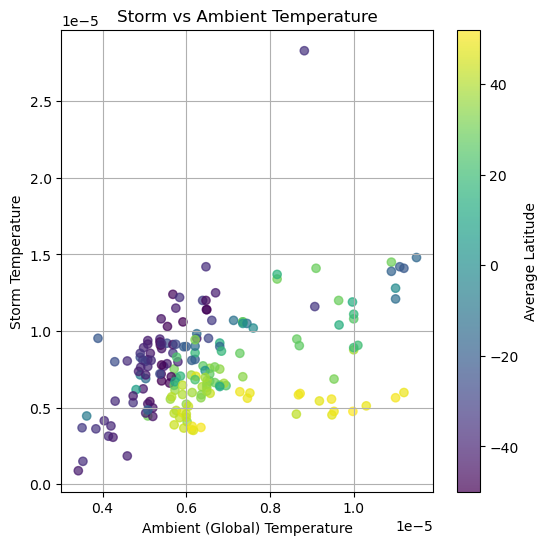

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df = pd.read_csv("possible_detection_J_MCS.csv")

# Create average latitude column
df["avg_lat"] = (df["min_lat"] + df["max_lat"]) / 2

# ---- Scatter: Water Content ----
plt.figure(figsize=(6, 6))

sc1 = plt.scatter(
    df["global_water_mean"],
    df["storm_water_mean"],
    c=df["avg_lat"],          # Colour by latitude
    cmap="viridis",           # Colormap
    alpha=0.7
)

plt.title("Storm vs Ambient Water Content")
plt.xlabel("Ambient (Global) Water Content")
plt.ylabel("Storm Water Content")
plt.grid(True)

# Add colorbar
cbar1 = plt.colorbar(sc1)
cbar1.set_label("Average Latitude")

plt.show()

# ---- Scatter: Temperature ----
plt.figure(figsize=(6, 6))

sc2 = plt.scatter(
    df["global_temp_mean"],
    df["storm_temp_mean"],
    c=df["avg_lat"],          # Colour by latitude
    cmap="viridis",
    alpha=0.7
)

plt.title("Storm vs Ambient Temperature")
plt.xlabel("Ambient (Global) Temperature")
plt.ylabel("Storm Temperature")
plt.grid(True)

# Add colorbar
cbar2 = plt.colorbar(sc2)
cbar2.set_label("Average Latitude")

plt.show()

### Plot Storm Water/Temp vs Ambient wrt Solar Longitude

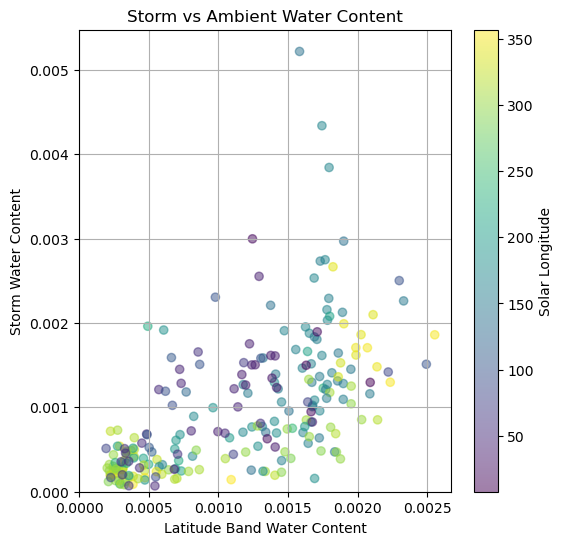

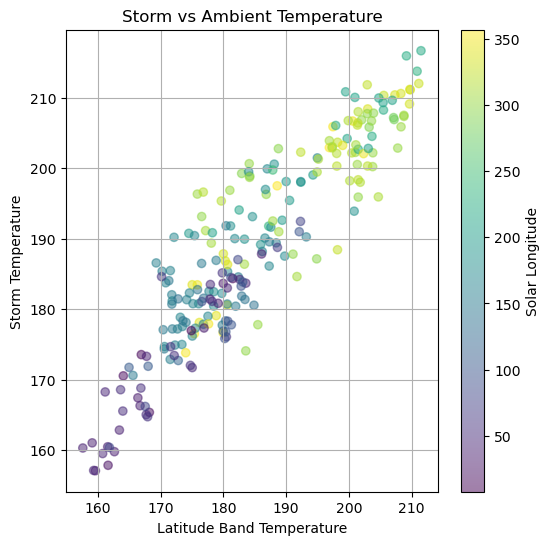

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Load your data
df_j = pd.read_csv("possible_detection_J_MCS.csv")
df_f = pd.read_csv("possible_detection_F_MCS.csv")
df = pd.concat([df_j, df_f])

# ---- Scatter: Water Content ----
plt.figure(figsize=(6, 6))
sc1 = plt.scatter(df["global_water_mean"], df["storm_water_mean"], c=df["L_s"], cmap="viridis", alpha=0.5)
plt.title("Storm vs Ambient Water Content")
plt.xlabel("Latitude Band Water Content")
plt.ylabel("Storm Water Content")
plt.grid(True)
plt.axis('auto')
plt.xlim(left=0)
plt.ylim(bottom=0)
cbar1 = plt.colorbar(sc1)
cbar1.set_label("Solar Longitude")
plt.show()

# ---- Scatter: Temperature ----
plt.figure(figsize=(6, 6))
sc2 = plt.scatter(df["global_temp_mean"], df["storm_temp_mean"], c=df["L_s"], cmap="viridis", alpha=0.5)
plt.title("Storm vs Ambient Temperature")
plt.xlabel("Latitude Band Temperature")
plt.ylabel("Storm Temperature")
plt.grid(True)
plt.axis('auto')
cbar2 = plt.colorbar(sc2)
cbar2.set_label("Solar Longitude")
plt.show()

### Water/Temp Over Time

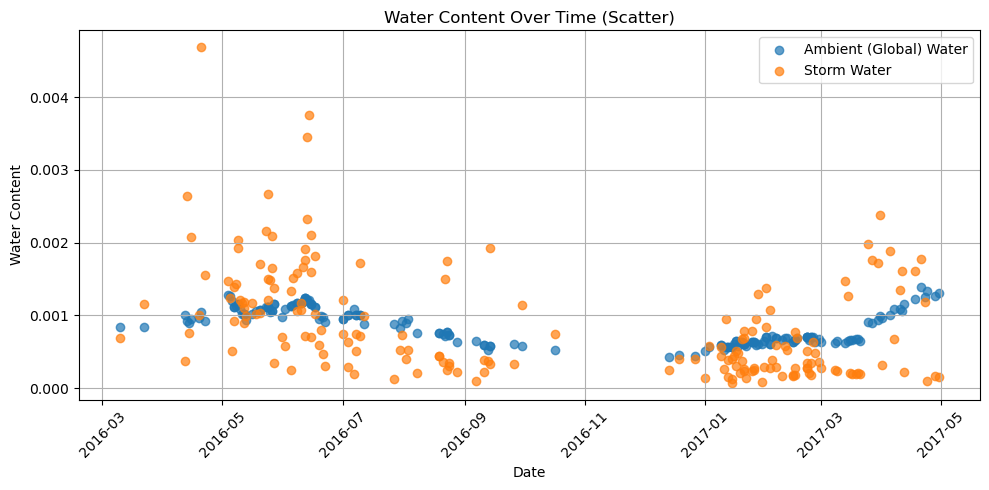

In [6]:
# Convert date column (dd/mm/yyyy format)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort by date (important for clean plotting)
df = df.sort_values("Date")

# ---- Plot: Water Content vs Date ----
plt.figure(figsize=(10, 5))

plt.scatter(df["Date"], df["global_water_mean"], label="Ambient (Global) Water", alpha=0.7)
plt.scatter(df["Date"], df["storm_water_mean"], label="Storm Water", alpha=0.7)

plt.title("Water Content Over Time (Scatter)")
plt.xlabel("Date")
plt.ylabel("Water Content")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

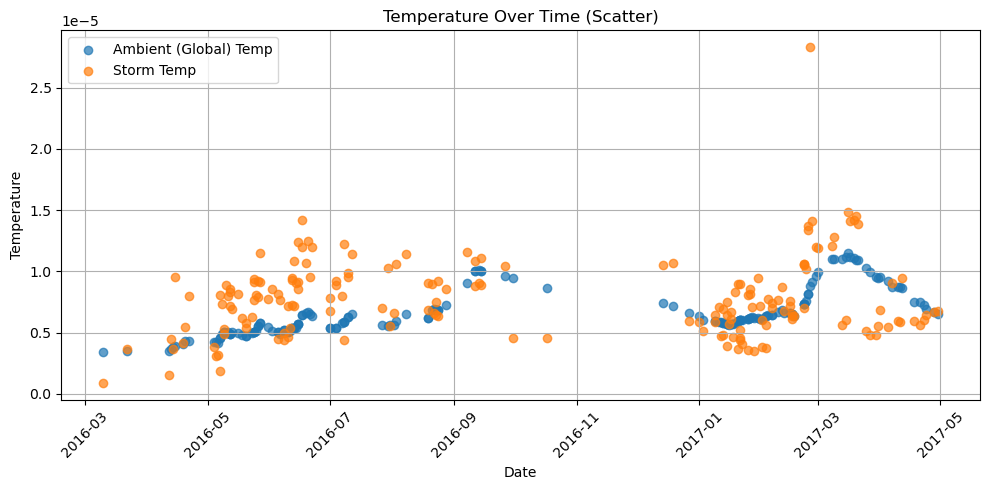

In [7]:
# Convert date column (dd/mm/yyyy format)
df["Date"] = pd.to_datetime(df["Date"], dayfirst=True)

# Sort by date (important for clean plotting)
df = df.sort_values("Date")

# ---- Plot: Water Content vs Date ----
plt.figure(figsize=(10, 5))

plt.scatter(df["Date"], df["global_temp_mean"], label="Ambient (Global) Temp", alpha=0.7)
plt.scatter(df["Date"], df["storm_temp_mean"], label="Storm Temp", alpha=0.7)

plt.title("Temperature Over Time (Scatter)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid(True)

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

### Difference in Water and Difference in Temp Correlation

Correlation between ΔWater and ΔTemp: -0.112


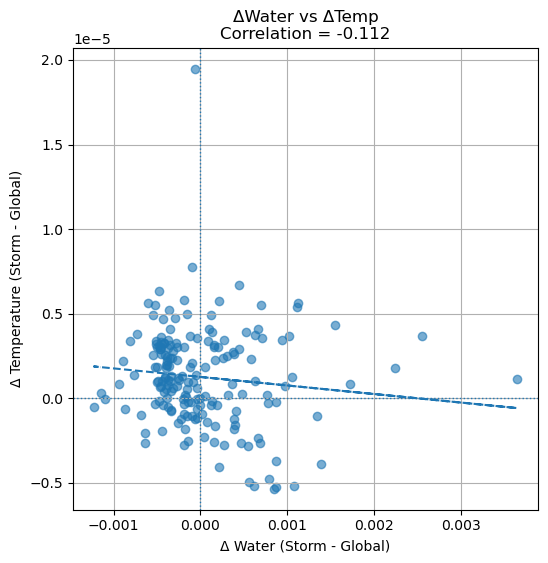

In [8]:
# ---- Compute differences ----
df["delta_water"] = df["storm_water_mean"] - df["global_water_mean"]
df["delta_temp"] = df["storm_temp_mean"] - df["global_temp_mean"]

# ---- Correlation ----
corr = df["delta_water"].corr(df["delta_temp"])
print(f"Correlation between ΔWater and ΔTemp: {corr:.3f}")

# ---- Scatter Plot ----
plt.figure(figsize=(6, 6))
plt.scatter(df["delta_water"], df["delta_temp"], alpha=0.6)

plt.xlabel("Δ Water (Storm - Global)")
plt.ylabel("Δ Temperature (Storm - Global)")
plt.title(f"ΔWater vs ΔTemp\nCorrelation = {corr:.3f}")
plt.grid(True)

# ---- Best-fit line ----
x = df["delta_water"]
y = df["delta_temp"]

m, b = np.polyfit(x, y, 1)
plt.plot(x, m*x + b, linestyle="--")

# ---- Reference lines at zero ----
plt.axhline(0, linestyle=":", linewidth=1)
plt.axvline(0, linestyle=":", linewidth=1)

plt.show()

### Difference in Water/Temperature Given Latitude

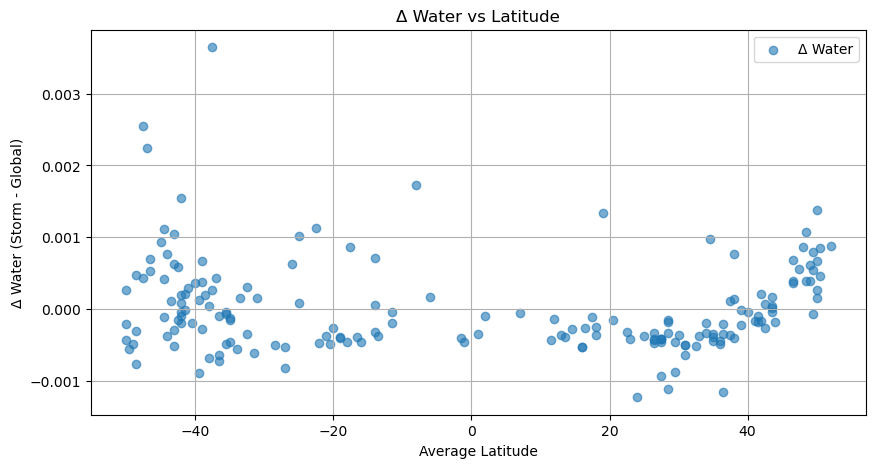

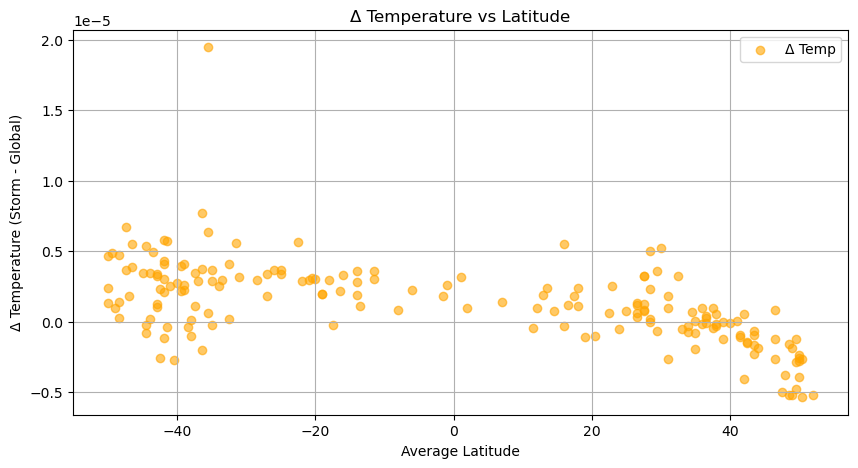

In [5]:
# ---- Compute derived variables ----
df["delta_water"] = df["storm_water_mean"] - df["global_water_mean"]
df["delta_temp"] = df["storm_temp_mean"] - df["global_temp_mean"]
df["avg_lat"] = (df["min_lat"] + df["max_lat"]) / 2

# ---- Plot: ΔWater vs Latitude ----
plt.figure(figsize=(10, 5))

plt.scatter(df["avg_lat"], df["delta_water"], alpha=0.6, label="Δ Water")
plt.xlabel("Average Latitude")
plt.ylabel("Δ Water (Storm - Global)")
plt.title("Δ Water vs Latitude")
plt.grid(True)
plt.legend()

plt.show()

# ---- Plot: ΔTemp vs Latitude ----
plt.figure(figsize=(10, 5))

plt.scatter(df["avg_lat"], df["delta_temp"], alpha=0.6, color="orange", label="Δ Temp")
plt.xlabel("Average Latitude")
plt.ylabel("Δ Temperature (Storm - Global)")
plt.title("Δ Temperature vs Latitude")
plt.grid(True)
plt.legend()

plt.show()

### 2 Mixture Model, L_s as Determinant of Temperature

--- STATISTICAL RESULTS ---
Mann-Whitney U Test p-value = 1.7701e-18
Headline Separation Score (AUC-ROC) = 0.8310


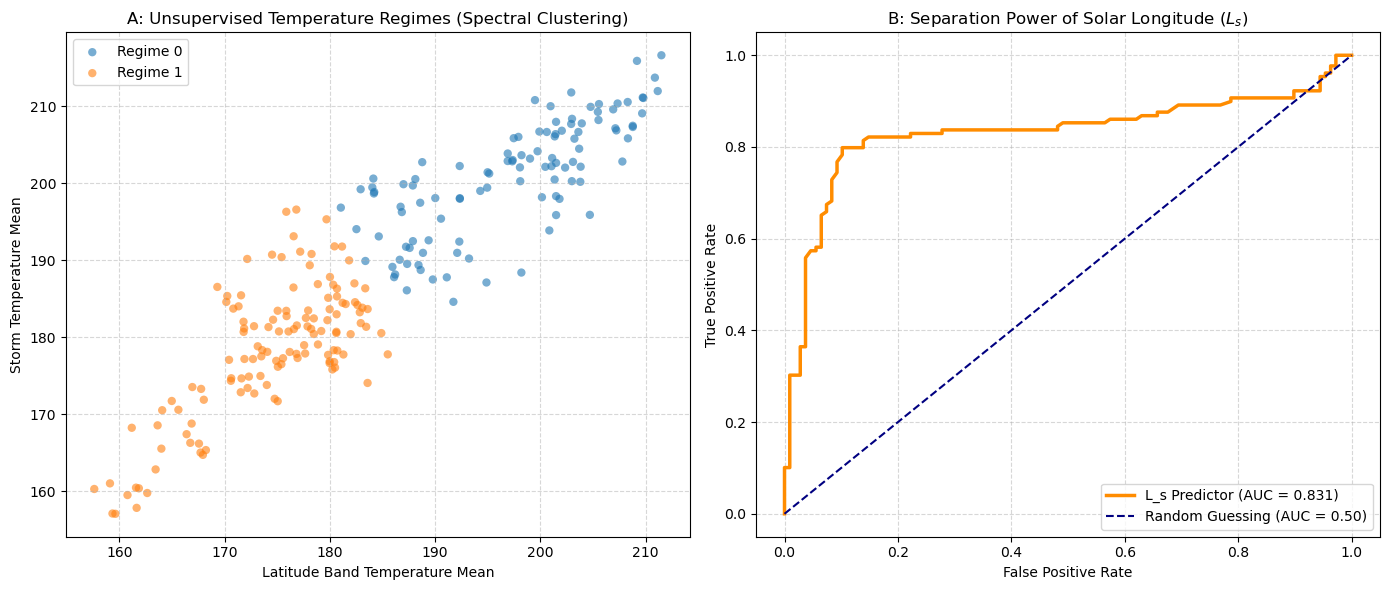

In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.cluster import SpectralClustering
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt

df_j = pd.read_csv("possible_detection_J_MCS.csv")
df_f = pd.read_csv("possible_detection_F_MCS_latband.csv")
df = pd.concat([df_j, df_f])

df = df.dropna(subset=['L_s', 'storm_temp_mean', 'global_temp_mean'])

# Extract the bivariate temperature space
X_temp = df[['storm_temp_mean', 'global_temp_mean']]

# Fit a Spectral Clustering model to identify the 2 distinct distributions
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
df['cluster_label'] = spectral.fit_predict(X_temp)

# Split Solar Longitude (L_s) values based on the assigned GMM clusters
ls_group_0 = df[df['cluster_label'] == 0]['L_s']
ls_group_1 = df[df['cluster_label'] == 1]['L_s']

# Perform a non-parametric Mann-Whitney U test to check if L_s of distributions are significantly different
u_stat, p_value = mannwhitneyu(ls_group_0, ls_group_1, alternative='two-sided')

# Determine if Solar Longitude (L_s) can cleanly discriminate between the 2 clusters
X_ls = df[['L_s']]
y_cluster = df['cluster_label']

# Fit a Logistic Regression classifier
lr_model = LogisticRegression()
lr_model.fit(X_ls, y_cluster)

# Get the continuous classification probabilities for the ROC curve calculation
y_probs = lr_model.predict_proba(X_ls)[:, 1]

# Calculate the single definitive score (Area Under the ROC Curve)
auc_score = roc_auc_score(y_cluster, y_probs)

print("--- STATISTICAL RESULTS ---")
print(f"Mann-Whitney U Test p-value = {p_value:.4e}")
print(f"Headline Separation Score (AUC-ROC) = {auc_score:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: Temperature Scatter plot shaded by the uncovered GMM clusters
colors = ['#1f77b4', '#ff7f0e']
for cluster_id in [0, 1]:
    sub_cluster = df[df['cluster_label'] == cluster_id]
    ax1.scatter(sub_cluster['global_temp_mean'], sub_cluster['storm_temp_mean'], 
                c=colors[cluster_id], label=f'Regime {cluster_id}', alpha=0.6, edgecolors='none')
ax1.set_xlabel('Latitude Band Temperature Mean')
ax1.set_ylabel('Storm Temperature Mean')
ax1.set_title('A: Unsupervised Temperature Regimes (Spectral Clustering)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot B: ROC Curve showing how well L_s separates them
fpr, tpr, _ = roc_curve(y_cluster, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'L_s Predictor (AUC = {auc_score:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('B: Separation Power of Solar Longitude ($L_s$)')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()

--- STATISTICAL RESULTS ---
Mann-Whitney U Test p-value = 1.7701e-18
Headline Separation Score (AUC-ROC) = 0.7007


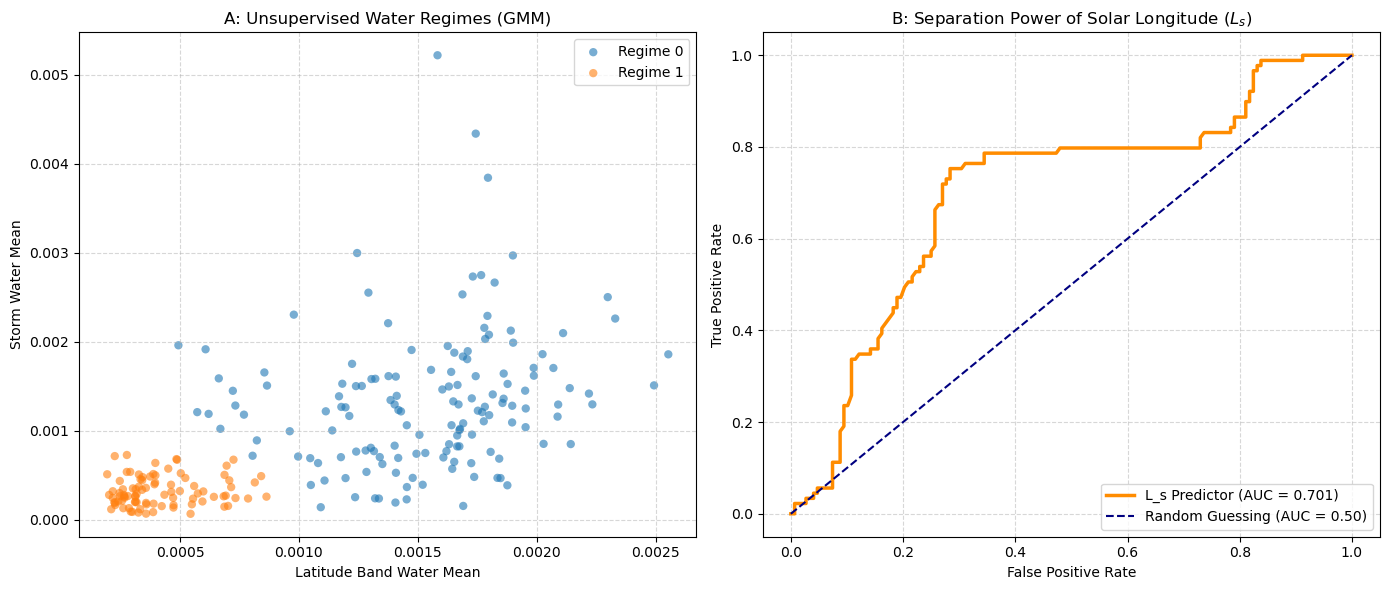

In [10]:
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.stats import mannwhitneyu
import matplotlib.pyplot as plt
from sklearn.cluster import SpectralClustering

df_j = pd.read_csv("possible_detection_J_MCS.csv")
df_f = pd.read_csv("possible_detection_F_MCS_latband.csv")
df = pd.concat([df_j, df_f])
df = df.dropna(subset=['L_s', 'storm_water_mean', 'global_water_mean'])

X_temp = df[['storm_water_mean', 'global_water_mean']]
spectral = SpectralClustering(n_clusters=2, affinity='nearest_neighbors', random_state=42)
df['cluster_label'] = spectral.fit_predict(X_temp)

ls_group_0 = df[df['cluster_label'] == 0]['L_s']
ls_group_1 = df[df['cluster_label'] == 1]['L_s']

# Determine if Solar Longitude (L_s) can cleanly discriminate between the 2 clusters
X_ls = df[['L_s']]
y_cluster = df['cluster_label']

# Fit a Logistic Regression classifier
lr_model = LogisticRegression()
lr_model.fit(X_ls, y_cluster)

# Get the continuous classification probabilities for the ROC curve calculation
y_probs = lr_model.predict_proba(X_ls)[:, 1]

# Calculate the single definitive score (Area Under the ROC Curve)
auc_score = roc_auc_score(y_cluster, y_probs)

print("--- STATISTICAL RESULTS ---")
print(f"Mann-Whitney U Test p-value = {p_value:.4e}")
print(f"Headline Separation Score (AUC-ROC) = {auc_score:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Subplot A: Temperature Scatter plot shaded by the uncovered GMM clusters
colors = ['#1f77b4', '#ff7f0e']
for cluster_id in [0, 1]:
    sub_cluster = df[df['cluster_label'] == cluster_id]
    ax1.scatter(sub_cluster['global_water_mean'], sub_cluster['storm_water_mean'], 
                c=colors[cluster_id], label=f'Regime {cluster_id}', alpha=0.6, edgecolors='none')
ax1.set_xlabel('Latitude Band Water Mean')
ax1.set_ylabel('Storm Water Mean')
ax1.set_title('A: Unsupervised Water Regimes (Spectral Clustering)')
ax1.legend()
ax1.grid(True, linestyle='--', alpha=0.5)

# Subplot B: ROC Curve showing how well L_s separates them
fpr, tpr, _ = roc_curve(y_cluster, y_probs)
ax2.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'L_s Predictor (AUC = {auc_score:.3f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Guessing (AUC = 0.50)')
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('B: Separation Power of Solar Longitude ($L_s$)')
ax2.legend(loc="lower right")
ax2.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()